### Importance Sampling
Implement Importance Sampling by defining the target and proposal distributions, generating samples from the proposal, calculating importance weights, and defining a function of interest. Then calculate the Importance Sampling estimator for the expected value of the function and visualize the distributions and weighted samples.

Define a target distribution (P) and a proposal distribution (Q) by specifying their parameters and implementing functions to calculate their PDFs.


In [ ]:
import numpy as np
from scipy import stats

# Define parameters for the target distribution (P)
target_mu, target_sigma = 0.0, 1.0

# Define parameters for the proposal distribution (Q)
proposal_mu, proposal_sigma = 2.0, 1.5

# Function for the target PDF
def target_pdf(x):
    return stats.norm.pdf(x, loc=target_mu, scale=target_sigma)

# Function for the proposal PDF
def proposal_pdf(x):
    return stats.norm.pdf(x, loc=proposal_mu, scale=proposal_sigma)

# 5. Print the defined parameters
print(f"Target Distribution Parameters:\n  Mean (mu): {target_mu}\n  Standard Deviation (sigma): {target_sigma}")
print(f"\nProposal Distribution Parameters:\n  Mean (mu): {proposal_mu}\n  Standard Deviation (sigma): {proposal_sigma}")

Target Distribution Parameters:
  Mean (mu): 0.0
  Standard Deviation (sigma): 1.0

Proposal Distribution Parameters:
  Mean (mu): 2.0
  Standard Deviation (sigma): 1.5


Generate Samples from the chosen proposal distribution (Q).


In [ ]:
num_is_samples = 100000
samples_from_proposal = np.random.normal(loc=proposal_mu, scale=proposal_sigma, size=num_is_samples)

print(f"Generated {len(samples_from_proposal)} samples from the proposal distribution. \n"
f"First 5 samples: {samples_from_proposal[:5].round(2)}\n"
f"Mean of samples: {np.mean(samples_from_proposal):.2f}, "
f"Standard Deviation of samples: {np.std(samples_from_proposal):.2f}")

Generated 100000 samples from the proposal distribution. 
First 5 samples: [ 0.46  1.33  0.55  2.1  -0.4 ]
Mean of samples: 2.00, Standard Deviation of samples: 1.50


Calculate Importance Weights

For each sample drawn from the proposal distribution, calculate its importance weight as the ratio of the target PDF to the proposal PDF, i.e., w_i = P(x_i) / Q(x_i).


In [ ]:
target_pdf_values = target_pdf(samples_from_proposal)
proposal_pdf_values = proposal_pdf(samples_from_proposal)

importance_weights = target_pdf_values / proposal_pdf_values

print(f"First 5 importance weights: {importance_weights[:5].round(4)} \n"
f"Sum of all importance weights: {np.sum(importance_weights):.2f}")

First 5 importance weights: [2.2733 0.6878 2.0612 0.1662 4.9666] 
Sum of all importance weights: 99326.66


Define a Function of Interest

Define a function f(x) for which we want to estimate its expected value under the target distribution. This function will be applied to the samples drawn from the proposal distribution.

Importance Sampling estimator for the expected value of the function. This involves applying $f_x$ to the samples_from_proposal, multiplying by the importance_weights, and then taking the average.


In [ ]:
f_x_values = f_x(samples_from_proposal)
is_estimate = np.sum(f_x_values * importance_weights) / num_is_samples

print(f"Importance Sampling Estimate of E[f(x)]: {is_estimate:.4f}")

Importance Sampling Estimate of E[f(x)]: -0.0035


Visualize Distributions and Weighted Samples

Understand how the proposal distribution covers the target distribution and how weights are assigned.

To effectively show Importance Sampling, show:
- The PDFs of both the target and proposal distributions to understand their overlap and differences.
- A scatter plot of the samples drawn from the proposal distribution.
- Crucially, I will visualize these samples with their importance weights incorporated to demonstrate how samples from the proposal distribution are re-weighted to represent the target distribution, especially highlighting regions where the proposal is a poor fit for the target.

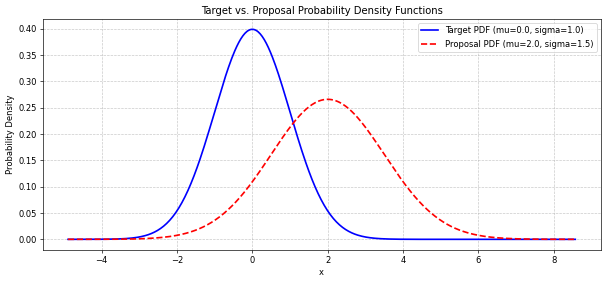

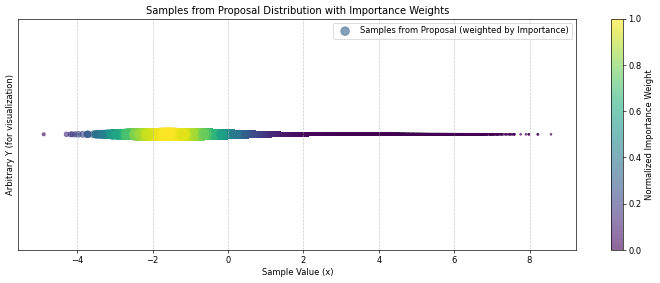

In [ ]:
import matplotlib.pyplot as plt

# Plot Target and Proposal PDFs
x_vals = np.linspace(min(min(samples_from_proposal), target_mu - 4 * target_sigma, proposal_mu - 4 * proposal_sigma), max(max(samples_from_proposal), target_mu + 4 * target_sigma, proposal_mu + 4 * proposal_sigma), 500)

plt.figure(figsize=(12, 5), dpi=60)
plt.plot(x_vals, target_pdf(x_vals), label=f'Target PDF (mu={target_mu}, sigma={target_sigma})', color='blue', linewidth=2)
plt.plot(x_vals, proposal_pdf(x_vals), label=f'Proposal PDF (mu={proposal_mu}, sigma={proposal_sigma})', color='red', linestyle='--', linewidth=2)
plt.title('Target vs. Proposal Probability Density Functions')
plt.xlabel('x') ; plt.ylabel('Probability Density')
plt.legend() ; plt.grid(True, linestyle='--', alpha=0.7) ; plt.show()

# Scatter plot of samples weighted by importance weights
# Normalize weights for better visualization as marker size or color intensity
# Adding a small constant to size to ensure smallest weights are still visible
normalized_weights = importance_weights / np.max(importance_weights)
scaled_sizes = normalized_weights * 200 + 5 # Scale for marker size, add offset

plt.figure(figsize=(15, 5), dpi=60)
plt.scatter(samples_from_proposal, np.zeros_like(samples_from_proposal),
            s=scaled_sizes, c=normalized_weights, cmap='viridis', alpha=0.6,
            label='Samples from Proposal (weighted by Importance)')
plt.title('Samples from Proposal Distribution with Importance Weights')
plt.xlabel('Sample Value (x)')
plt.ylabel('Arbitrary Y (for visualization)')
plt.colorbar(label='Normalized Importance Weight')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend() ; plt.yticks([]) # Hide y-axis ticks as they are not meaningful
plt.show()

**Overlap**: There is a significant overlap between the two distributions, which is crucial for Importance Sampling to work effectively. If there was no overlap, some importance weights would be zero, making the estimation biased.

**Coverage**: The proposal distribution is wider (sigma=1.5 vs sigma=1) and shifted to the right (mu=2 vs mu=0) relative to the target. This means the proposal covers regions where the target distribution has lower probability density (tails) more effectively than a proposal centered at 0 with a smaller standard deviation would. However, the shift in mean also means that samples drawn from the proposal might be less frequent in the high-density region of the target distribution around x=0 if not for the wider spread.

**Weight Distribution**: Samples from the proposal distribution that are closer to the target's mean (`0`) or within its high-density region received higher importance weights, effectively shifting the representation of the samples towards the target distribution. Samples in the tails of the proposal distribution, where the target's density is very low, received very small weights, correctly down-weighting their influence.

In this specific case, for estimating the mean of a Gaussian, a proposal distribution that is sufficiently broad and has reasonable overlap with the target, while not being drastically shifted, tends to be effective. The chosen proposal, while not identical to the target, performed well in estimating the mean. For more complex functions or target distributions, careful selection of the proposal distribution is critical to minimize variance in the estimator and ensure accurate results.